Testing F(x) = x^5 + x - 1

Iter  | x_n          | f(x_n)          | Error          
-------------------------------------------------------
0     | 1.000000     | 1.000000e+00    | 1.666667e-01   
1     | 0.833333     | 2.352109e-01    | 6.895122e-02   
2     | 0.764382     | 2.532928e-02    | 9.357248e-03   
3     | 0.755025     | 3.862882e-04    | 1.471655e-04   
4     | 0.754878     | 9.319893e-08    | 3.552343e-08   
-------------------------------------------------------

Converged to root: 0.754878 after 5 iterations.


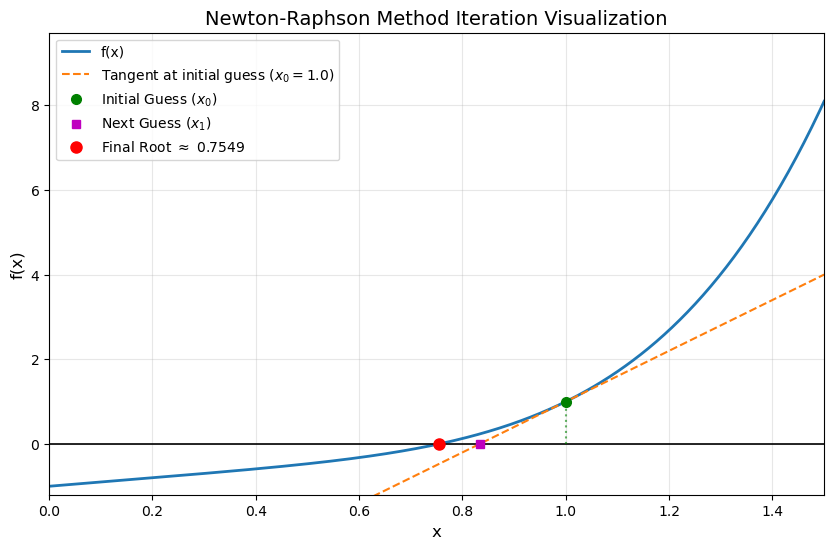

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# Task 1 & Quintic Test Functions Definition
# ==========================================

# 1. F(x) = x^5 + x - 1
def f1(x):  return x**5 + x - 1
def df1(x): return 5 * x**4 + 1

# 2. F(x) = x^5 + 5x^3 - 4x + 1
def f2(x):  return x**5 + 5 * x**3 - 4 * x + 1
def df2(x): return 5 * x**4 + 15 * x**2 - 4

# 3. F(x) = x^5 + 2x^4 - x - 3
def f3(x):  return x**5 + 2 * x**4 - x - 3
def df3(x): return 5 * x**4 + 8 * x**3 - 1

# 4. F(x) = x^5 - 10
def f4(x):  return x**5 - 10
def df4(x): return 5 * x**4

# 5. F(x) = x^5 + 2x^2 + x - 0.5
def f5(x):  return x**5 + 2 * x**2 + x - 0.5
def df5(x): return 5 * x**4 + 4 * x + 1


# ==========================================
# Task 2: Implementation of the Algorithm
# ==========================================

def newton_raphson(f, df, x0, tolerance=1e-7, max_iter=100):
    """
    Finds a root of a function using the Newton-Raphson method.
    
    Returns:
        tuple: (final_root, list_of_guesses_history)
    """
    print(f"{'Iter':<5} | {'x_n':<12} | {'f(x_n)':<15} | {'Error':<15}")
    print("-" * 55)
    
    x_history = [x0]
    x_n = x0
    
    for i in range(max_iter):
        fx = f(x_n)
        dfx = df(x_n)
        
        # Safety Check: Prevent division by zero
        if abs(dfx) < 1e-14:
            print(f"\nError: Derivative is close to zero at x = {x_n:.6f}. Stopping to prevent division by zero.")
            return None, x_history
            
        # Update guess
        x_next = x_n - fx / dfx
        error = abs(x_next - x_n)
        x_history.append(x_next)
        
        # Tabular output
        print(f"{i:<5} | {x_n:<12.6f} | {fx:<15.6e} | {error:<15.6e}")
        
        # Convergence Check
        if error < tolerance:
            print("-" * 55)
            print(f"\nConverged to root: {x_next:.6f} after {i+1} iterations.")
            return x_next, x_history
            
        x_n = x_next
        
    print("\nWarning: Maximum iterations reached without convergence.")
    return x_n, x_history


# ==========================================
# Task 3: Visualization (with Challenge)
# ==========================================

def visualize_newton(f, df, root, x_history, x_range=(-2, 2)):
    """
    Plots the function, axes, the calculated root, and the first tangent line.
    """
    # Generate points for the function curve
    x_vals = np.linspace(x_range[0], x_range[1], 500)
    y_vals = f(x_vals)
    
    plt.figure(figsize=(10, 6))
    
    # 1. Plot function and main axes
    plt.plot(x_vals, y_vals, label='f(x)', color='#1f77b4', linewidth=2)
    plt.axhline(0, color='black', linewidth=1.2) # X-axis
    plt.axvline(0, color='black', linewidth=1.2) # Y-axis
    
    # 2. Optional Challenge: Plot the tangent line of the very first iteration
    if len(x_history) > 1:
        x0 = x_history[0]
        y0 = f(x0)
        slope = df(x0)
        x1 = x_history[1]
        
        # Tangent line equation: y = m(x - x0) + y0
        tangent_y = slope * (x_vals - x0) + y0
        
        plt.plot(x_vals, tangent_y, '--', color='#ff7f0e', label=f'Tangent at initial guess ($x_0={x0}$)')
        plt.plot(x0, y0, 'go', markersize=7, label=f'Initial Guess ($x_0$)')
        
        # Draw a dotted line dropping from the tangent intersection (x1) to the axis
        plt.plot([x0, x0], [0, y0], 'g:', alpha=0.6) # Line from x-axis to f(x0)
        plt.plot(x1, 0, 'ms', markersize=6, label=f'Next Guess ($x_1$)') # Mark where tangent hits 0

    # 3. Mark the final root
    if root is not None:
        plt.plot(root, 0, 'ro', markersize=8, label=f'Final Root $\\approx$ {root:.4f}')

    # Visual polishing
    # Constrain y-axis so a steep tangent doesn't ruin the plot's scale
    y_min, y_max = min(y_vals), max(y_vals)
    plt.ylim(y_min - 0.2 * abs(y_min), y_max + 0.2 * abs(y_max))
    plt.xlim(x_range[0], x_range[1])
    
    plt.title('Newton-Raphson Method Iteration Visualization', fontsize=14)
    plt.xlabel('x', fontsize=12)
    plt.ylabel('f(x)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, alpha=0.3)
    plt.show()

# ==========================================
# Execution / Driver Code
# ==========================================
if __name__ == "__main__":
    # Let's test the first quintic function: f(x) = x^5 + x - 1
    # Initial guess = 1.0, Tolerance = 1e-6
    initial_guess = 1.0
    
    print("Testing F(x) = x^5 + x - 1\n")
    root, history = newton_raphson(f1, df1, initial_guess, tolerance=1e-6, max_iter=50)
    
    if root is not None:
        # Plot over a window that neatly frames the root and the initial guess
        visualize_newton(f1, df1, root, history, x_range=(0, 1.5))

Test 1: F(x) = x^5 + x - 1
Initial Guess (x0) = 1.0
Iter  | x_n          | f(x_n)          | Error          
-------------------------------------------------------
0     | 1.000000     | 1.000000e+00    | 1.666667e-01   
1     | 0.833333     | 2.352109e-01    | 6.895122e-02   
2     | 0.764382     | 2.532928e-02    | 9.357248e-03   
3     | 0.755025     | 3.862882e-04    | 1.471655e-04   
4     | 0.754878     | 9.319893e-08    | 3.552343e-08   
-------------------------------------------------------

Converged to root: 0.754878 after 5 iterations.
Rendering plot...



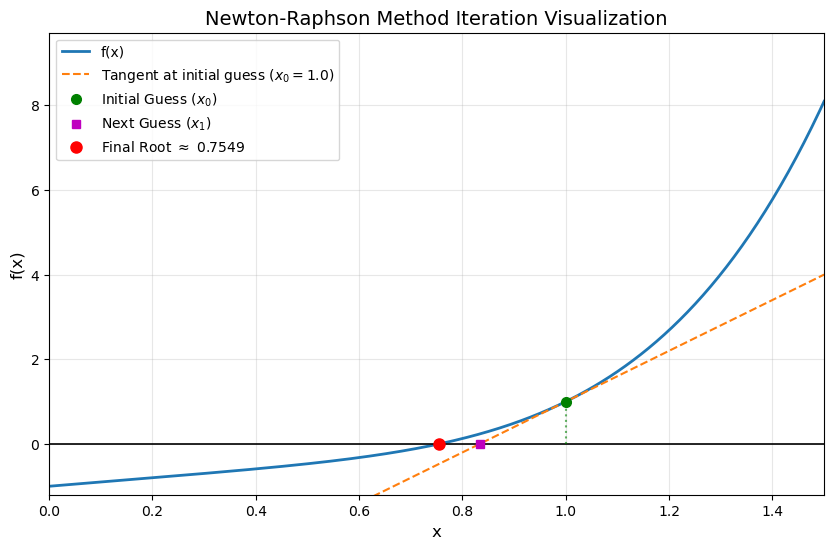

Test 2: F(x) = x^5 + 5x^3 - 4x + 1
Initial Guess (x0) = 0.0
Iter  | x_n          | f(x_n)          | Error          
-------------------------------------------------------
0     | 0.000000     | 1.000000e+00    | 2.500000e-01   
1     | 0.250000     | 7.910156e-02    | 2.599487e-02   
2     | 0.275995     | 2.738971e-03    | 9.683850e-04   
3     | 0.276963     | 4.084678e-06    | 1.448493e-06   
4     | 0.276965     | 9.162338e-12    | 3.249123e-12   
-------------------------------------------------------

Converged to root: 0.276965 after 5 iterations.
Rendering plot...



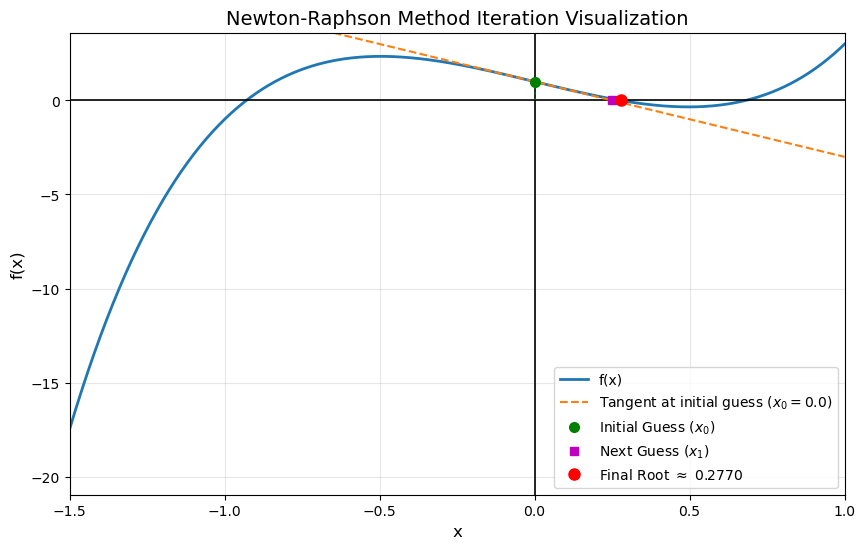

Test 3: F(x) = x^5 + 2x^4 - x - 3
Initial Guess (x0) = 1.0
Iter  | x_n          | f(x_n)          | Error          
-------------------------------------------------------
0     | 1.000000     | -1.000000e+00   | 8.333333e-02   
1     | 1.083333     | 1.635360e-01    | 1.018401e-02   
2     | 1.073149     | 2.757805e-03    | 1.777094e-04   
3     | 1.072972     | 8.266279e-07    | 5.329880e-08   
-------------------------------------------------------

Converged to root: 1.072972 after 4 iterations.
Rendering plot...



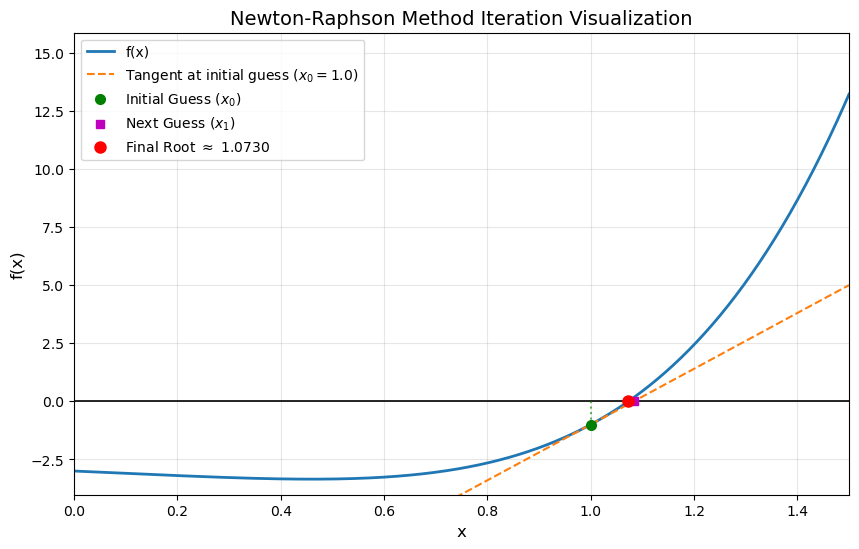

Test 4: F(x) = x^5 - 10
Initial Guess (x0) = 2.0
Iter  | x_n          | f(x_n)          | Error          
-------------------------------------------------------
0     | 2.000000     | 2.200000e+01    | 2.750000e-01   
1     | 1.725000     | 5.273744e+00    | 1.191222e-01   
2     | 1.605878     | 6.797849e-01    | 2.044332e-02   
3     | 1.585435     | 1.708881e-02    | 5.409395e-04   
4     | 1.584894     | 1.165719e-05    | 3.695078e-07   
-------------------------------------------------------

Converged to root: 1.584893 after 5 iterations.
Rendering plot...



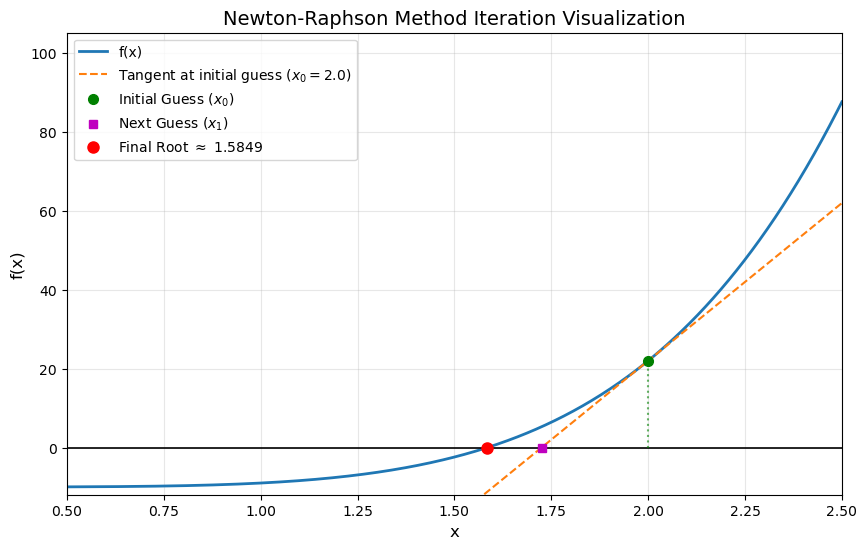

Test 5: F(x) = x^5 + 2x^2 + x - 0.5
Initial Guess (x0) = 0.0
Iter  | x_n          | f(x_n)          | Error          
-------------------------------------------------------
0     | 0.000000     | -5.000000e-01   | 5.000000e-01   
1     | 0.500000     | 5.312500e-01    | 1.603774e-01   
2     | 0.339623     | 7.482810e-02    | 3.085681e-02   
3     | 0.308766     | 2.244894e-03    | 9.843831e-04   
4     | 0.307781     | 2.222356e-06    | 9.764331e-07   
-------------------------------------------------------

Converged to root: 0.307780 after 5 iterations.
Rendering plot...



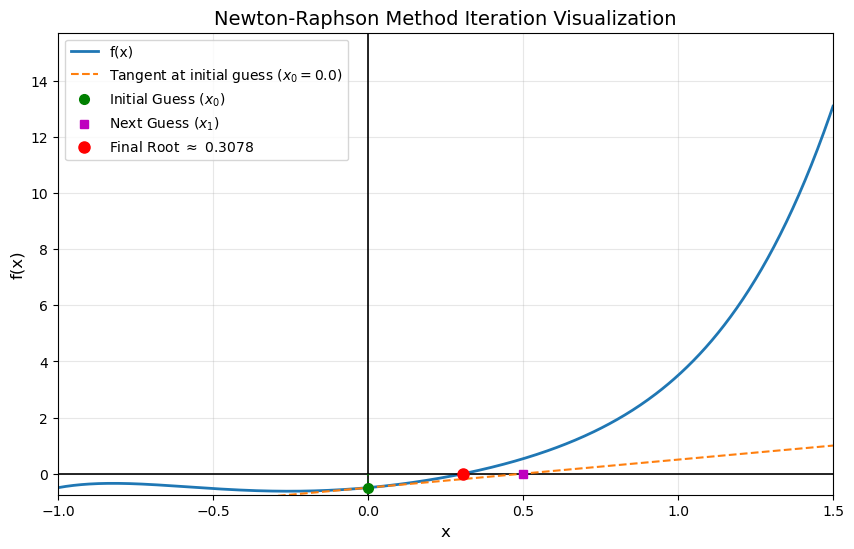

In [8]:
if __name__ == "__main__":
    # Define a list of dictionaries containing our functions, derivatives, 
    # display names, appropriate initial guesses, and plotting ranges.
    test_suite = [
        {
            "name": "F(x) = x^5 + x - 1",
            "f": f1, "df": df1,
            "x0": 1.0, "x_range": (0, 1.5)
        },
        {
            "name": "F(x) = x^5 + 5x^3 - 4x + 1",
            "f": f2, "df": df2,
            "x0": 0.0, "x_range": (-1.5, 1.0)
        },
        {
            "name": "F(x) = x^5 + 2x^4 - x - 3",
            "f": f3, "df": df3,
            "x0": 1.0, "x_range": (0.0, 1.5)
        },
        {
            "name": "F(x) = x^5 - 10",
            "f": f4, "df": df4,
            "x0": 2.0, "x_range": (0.5, 2.5)
        },
        {
            "name": "F(x) = x^5 + 2x^2 + x - 0.5",
            "f": f5, "df": df5,
            "x0": 0.0, "x_range": (-1.0, 1.5)
        }
    ]

    # Loop through each test case and run the algorithm
    for i, test in enumerate(test_suite, start=1):
        print("=" * 55)
        print(f"Test {i}: {test['name']}")
        print(f"Initial Guess (x0) = {test['x0']}")
        print("=" * 55)
        
        # Run Newton-Raphson
        root, history = newton_raphson(
            f=test["f"], 
            df=test["df"], 
            x0=test["x0"], 
            tolerance=1e-6, 
            max_iter=50
        )
        
        # Visualize the result if a root was found
        if root is not None:
            # We add a pause to the plots so they render one by one 
            # without overlapping or crashing the script.
            print("Rendering plot...\n")
            visualize_newton(
                f=test["f"], 
                df=test["df"], 
                root=root, 
                x_history=history, 
                x_range=test["x_range"]
            )